# Advanced Certification Program in Computational Data Science

##  A program by IISc and TalentSprint

### Mini Project 1: Market Basket analysis

## Learning Objectives

At the end of the experiment, you will be able to:

* extract summary level insight from a given dataset

* Integrate the data and identify the underlying pattern or structure

* understand the fundamentals of market basket analysis

* construct "rules" that provide concrete recommendations for businesses

## Dataset

The dataset chosen for this mini project is **Instacart Dataset**. The dataset is anonymized and contains a sample of over 3 million grocery orders from more than 200,000 Instacart users. For each user, there are orders between 4 and 100, with the sequence of products purchased in each order. The dataset also includes the products in each order, the time of day and day of week of each order, the name and aisle/department of each product, which are stored across various files.

## Problem Statement


Extract association rules and find groups of frequently purchased items from a large-scale grocery orders dataset.

## Grading = 10 Points

#### Import required packages

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

## **Stage 1**: Data Wrangling

We have five different files:

    - orders.csv
    - order_products__train.csv
    - products.csv
    - aisles.csv
    - departments.csv
	
These files contain the neccesary data to solve the problem. Load all the files correctly, after observing the header level details, data records etc
	
**Hint:** Use `read_csv` from pandas

In [3]:
#@title Download the data
!wget -qq https://cdn.iisc.talentsprint.com/CDS/Datasets/Instacart.zip
!unzip -qq Instacart.zip

### Load the data

Load all the given datasets

In [4]:
orders = pd.read_csv("/content/Instacart/orders.csv")
products = pd.read_csv("/content/Instacart/products.csv")
dept = pd.read_csv("/content/Instacart/departments.csv")
aisle = pd.read_csv("/content/Instacart/aisles.csv")
order_prod_train = pd.read_csv("/content/Instacart/order_products__train.csv")

In [5]:
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [6]:
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [7]:
dept.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [8]:
aisle.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [9]:
order_prod_train.tail()

,order_id,product_id,add_to_cart_order,reordered
1384612,3421063,14233,3,1
1384613,3421063,35548,4,1
1384614,3421070,35951,1,1
1384615,3421070,16953,2,1
1384616,3421070,4724,3,1


### Data Integration (1 point)

As the required data is present in different files, we need to integrate all the five to make single dataframe/dataset. For that purpose, use the unique identifier provided in all the dataframes so that it can be used to map the data in different files correctly.

**Example:** `product_id` is available in both `products` dataframe and `order_products__train` dataframe, we can merge these two into a single dataframe based on `product_id`

**Hint:** [pd.merge](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.merge.html)

In [13]:
orders_merged_df = orders.merge(order_prod_train, how='inner', on='order_id')
orders_merged_df.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered
0,1187899,1,train,11,4,8,14.0,196,1,1
1,1187899,1,train,11,4,8,14.0,25133,2,1
2,1187899,1,train,11,4,8,14.0,38928,3,1
3,1187899,1,train,11,4,8,14.0,26405,4,1
4,1187899,1,train,11,4,8,14.0,39657,5,1


In [14]:
prod_orders_df = products.merge(order_prod_train, how='inner', on='product_id')
prod_orders_df.head()

,product_id,product_name,aisle_id,department_id,order_id,add_to_cart_order,reordered
0,1,Chocolate Sandwich Cookies,61,19,6695,7,1
1,1,Chocolate Sandwich Cookies,61,19,48361,9,0
2,1,Chocolate Sandwich Cookies,61,19,63770,4,0
3,1,Chocolate Sandwich Cookies,61,19,75339,9,0
4,1,Chocolate Sandwich Cookies,61,19,240996,3,1


### Understanding relationships and new insights from the data (3 points)

1.  How many times was each product ordered?

    **Hint:** group orders by product
    

2.  Find the number of orders per department and visualize using an appropriate plot


3.  On which day of the week do customers tend to buy more groceries? Which are the peak hours
of shopping? 

  * Find the frequency of orders on week days using an appropriate plot 
  * Find the frequency of orders during hours of the day using an appropriate plot?
  

4. Find the ratio of Re-ordered and Not Re-ordered products and visualize it

5. Plot the heatmap of Re-order ratio of the Day of week vs Hour of day 

In [17]:
prod_count = prod_orders_df.groupby(['product_id']).size()
display(prod_count)

product_id
1          76
2           4
3           6
4          22
5           1
         ... 
49682       5
49683    2413
49686       7
49687       1
49688       4
Length: 39123, dtype: int64

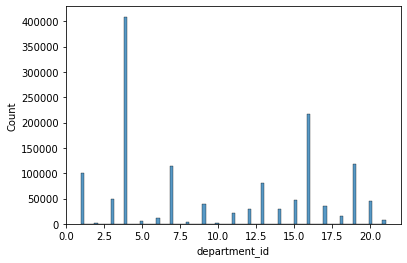

In [19]:
sns.histplot(data=prod_orders_df, x='department_id')

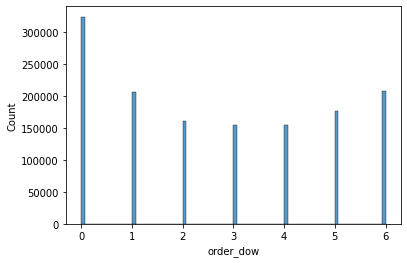

In [20]:
sns.histplot(data=orders_merged_df, x='order_dow')

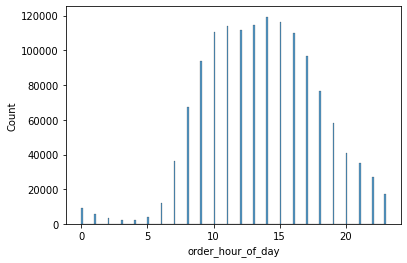

In [21]:
sns.histplot(data=orders_merged_df, x='order_hour_of_day')

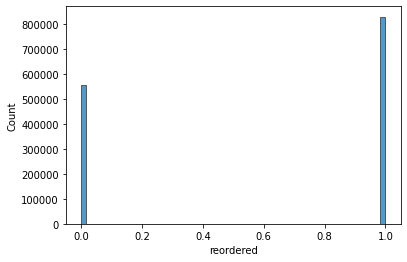

In [22]:
sns.histplot(data=prod_orders_df, x='reordered')

In [25]:
dow_hod_reorder_count = orders_merged_df.groupby(['order_dow','order_hour_of_day','reordered',]).size()
display(dow_hod_reorder_count)
dow_hod_reorder_count.head()

order_dow  order_hour_of_day  reordered
0          0                  0             662
                              1             906
           1                  0             464
                              1             660
           2                  0             342
                                           ... 
6          21                 1            3346
           22                 0            1512
                              1            2727
           23                 0            1210
                              1            1775
Length: 336, dtype: int64

order_dow  order_hour_of_day  reordered
0          0                  0            662
                              1            906
           1                  0            464
                              1            660
           2                  0            342
dtype: int64

In [38]:
orders_grouped_df = orders_merged_df.groupby(['order_dow','order_hour_of_day','reordered']).size().reset_index()
orders_grouped_df.head()

,order_dow,order_hour_of_day,reordered,0
0,0,0,0,662
1,0,0,1,906
2,0,1,0,464
3,0,1,1,660
4,0,2,0,342


In [40]:
orders_grouped_df.columns = ['order_dow','order_hour_of_day','reordered','count']
orders_grouped_df.head()

,order_dow,order_hour_of_day,reordered,count
0,0,0,0,662
1,0,0,1,906
2,0,1,0,464
3,0,1,1,660
4,0,2,0,342


In [ ]:
plt.figure(figsize=(20,20))
orders_grouped_df.pivot_table(columns=['order_dow','order_hour_of_day','reordered']).hist()

In [106]:
orders_pivot = orders_grouped_df.pivot_table(columns=['order_dow','order_hour_of_day','reordered'])
orders_pivot

order_dow            0                                               ...  \
order_hour_of_day   0         1         2         3         4        ...   
reordered            0    1    0    1    0    1    0    1    0    1  ...   
count              662  906  464  660  342  499  234  290  147  220  ...   

order_dow             6                                                        
order_hour_of_day    19          20          21          22          23        
reordered             0     1     0     1     0     1     0     1     0     1  
count              3921  5351  2329  3554  2068  3346  1512  2727  1210  1775  

[1 rows x 336 columns]

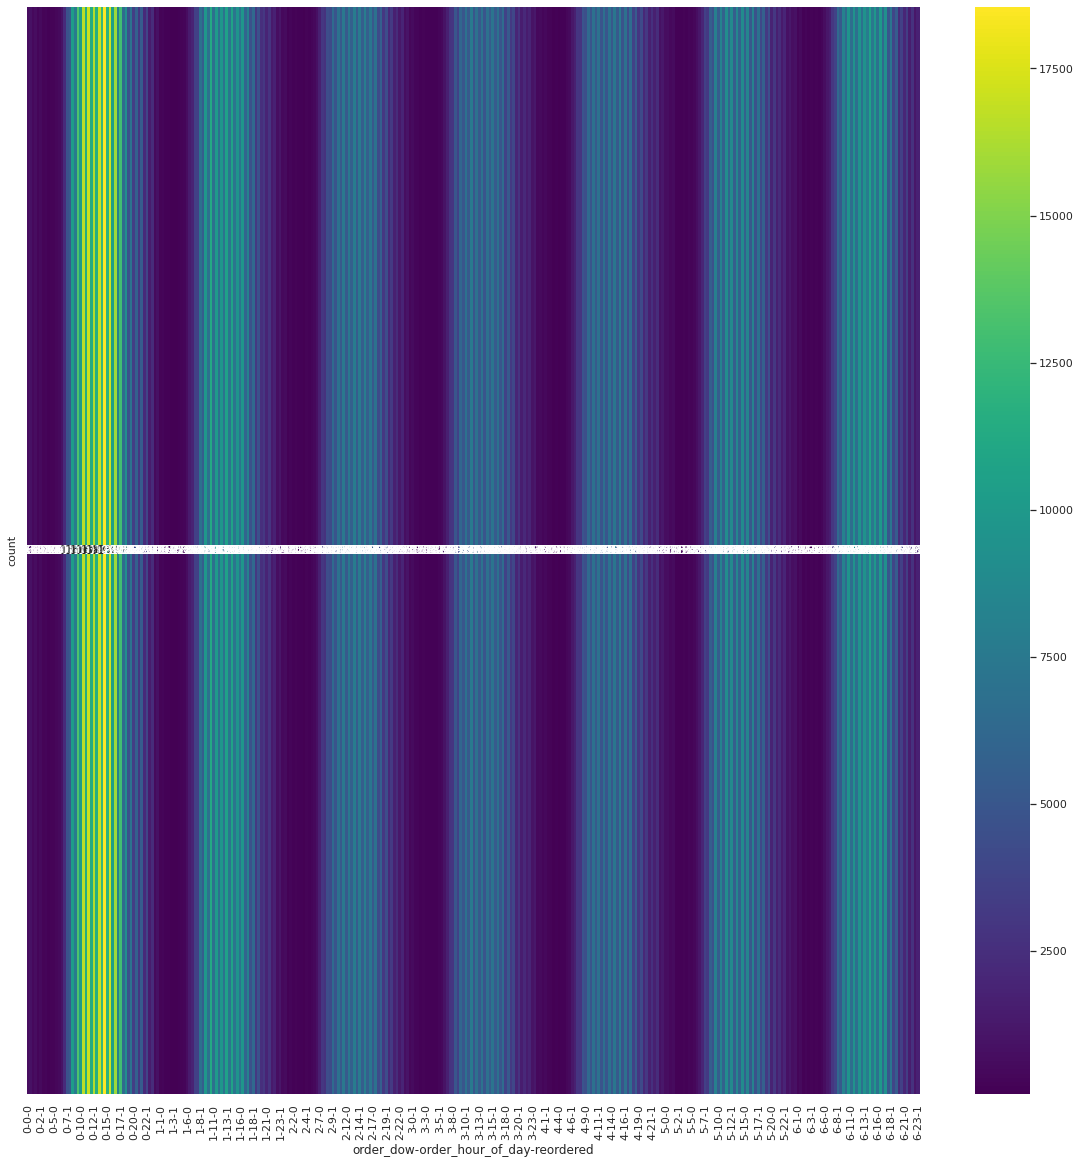

In [109]:
sns.set(rc = {'figure.figsize':(20,20)})
sns.heatmap(orders_pivot, annot=True, fmt="g", cmap='viridis')

## **Stage 2:** Create a basket (4 points)

As the dataset contains huge amount of data, let us take a subset of the data to extract the association rules from it. 

**Assumption:** Segment the data by considering the 100 most frequent ordered items. Please note it is just an assumption. You can consider 'n' frequent order items as per your choice.

**Hint:**

- Drop the unwanted columns

- Find the frequencies of orders based on the products and  consider the 100 most frequent order items.

    **Hint:** Count the frequencies of orders for each product_id using `groupby()` and `count()` respectively

- Extract the records of 100 most frequent items (which are extracted in previous step) from combined dataframe.

- Create a Pivot table with `order_id` as index and `product_name` as columns and `reorder` as values. 

    - set the `order_id` as index using set_index()
    - fill all the nan values with 0

- After performing the above step, there are a lot of zeros in the data, make sure that any positive values are converted to a 1 and anything less than 0 is set to 0.


In [50]:
prod_count = prod_orders_df.groupby(['product_id']).size().reset_index()
#display(prod_count)
prod_count.columns = ['product_id','count']
prod_count.head()

,product_id,count
0,1,76
1,2,4
2,3,6
3,4,22
4,5,1


In [55]:
prod_count.sort_values(by=['count'],ascending=False)
prod_count_sorted = prod_count.sort_values(by=['count'],ascending=False).head(100)
display(prod_count_sorted)

,product_id,count
19574,24852,18726
10367,13176,15480
16685,21137,10894
17300,21903,9784
37499,47626,8135
...,...,...
6456,8193,1418
7417,9387,1379
29671,37687,1362
16574,20995,1361


In [56]:
orders_merged_df.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered
0,1187899,1,train,11,4,8,14.0,196,1,1
1,1187899,1,train,11,4,8,14.0,25133,2,1
2,1187899,1,train,11,4,8,14.0,38928,3,1
3,1187899,1,train,11,4,8,14.0,26405,4,1
4,1187899,1,train,11,4,8,14.0,39657,5,1


In [58]:
orders_merged_df.drop(columns=['user_id','eval_set','order_number','order_dow','order_hour_of_day','days_since_prior_order','add_to_cart_order','reordered'],inplace=True)

In [64]:
orders_merged_df = orders_merged_df[orders_merged_df.product_id.isin(prod_count_sorted.product_id)]
orders_merged_df.product_id.value_counts() # Making sure its only the top 100 values

24852    18726
13176    15480
21137    10894
21903     9784
47626     8135
         ...  
8193      1418
9387      1379
37687     1362
20995     1361
34243     1351
Name: product_id, Length: 100, dtype: int64

In [65]:
orders_merged_df.head()

,order_id,product_id
0,1187899,196
8,1187899,27845
9,1187899,49235
16,1492625,22825
18,1492625,24852


In [66]:
basket = (orders_merged_df
          .groupby(['order_id', 'product_id'])
          .size().unstack().reset_index().fillna(0)
          .set_index('order_id'))
basket

product_id,196,4605,4920,5025,5077,5450,5785,5876,8174,8193,...,46667,46906,46979,47144,47209,47626,47766,48679,49235,49683
order_id,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
36,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
38,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
96,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
98,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3420998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3421049,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3421056,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [81]:
len(basket)

93850

## **Stage 3:** Apply Apriori algorithm (2 points)

- As the dataset contains huge amount of data, let us take a subset of the data to extract the association rules from it.

  **Assumption:** Segment the basket by considering 100000 records. Please note its just an assumption, you can consider 'n'  records as per your choice.

  **Hint:** [apriori](http://rasbt.github.io/mlxtend/api_subpackages/mlxtend.frequent_patterns/)

- Find the association rules and make a dataframe

In [84]:
frequent_itemsets = apriori(basket, min_support=0.005, use_colnames=True)

In [85]:
frequent_itemsets

,support,itemsets
0,0.016058,(196)
1,0.040085,(4605)
2,0.043250,(4920)
3,0.015397,(5025)
4,0.024486,(5077)
...,...,...
342,0.007565,"(13176, 47209, 21137)"
343,0.005296,"(13176, 47209, 21903)"
344,0.005658,"(13176, 47209, 27966)"
345,0.005157,"(24852, 47766, 21903)"


In [88]:
rules1 = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
rules1

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(4605),(21903),0.040085,0.104251,0.005796,0.144604,1.387069,0.001618,1.047174
1,(21903),(4605),0.104251,0.040085,0.005796,0.055601,1.387069,0.001618,1.016429
2,(24852),(4605),0.199531,0.040085,0.011412,0.057193,1.426790,0.003414,1.018146
3,(4605),(24852),0.040085,0.199531,0.011412,0.284689,1.426790,0.003414,1.119050
4,(26209),(4605),0.064283,0.040085,0.005285,0.082214,2.050991,0.002708,1.045903
...,...,...,...,...,...,...,...,...,...
479,"(47626, 47766)",(24852),0.014374,0.199531,0.005083,0.353595,1.772130,0.002215,1.238340
480,"(24852, 47766)",(47626),0.023612,0.086681,0.005083,0.215253,2.483278,0.003036,1.163839
481,(47626),"(24852, 47766)",0.086681,0.023612,0.005083,0.058636,2.483278,0.003036,1.037205
482,(24852),"(47626, 47766)",0.199531,0.014374,0.005083,0.025473,1.772130,0.002215,1.011389


In [95]:
rules2 = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.50)
rules2

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,"(47209, 27966)",(13176),0.010858,0.164944,0.005658,0.521099,3.159248,0.003867,1.743693


In [103]:
prod_orders_df[prod_orders_df.product_id.isin([47209, 27966,13176])].product_name.unique()

array(['Bag of Organic Bananas', 'Organic Raspberries',
       'Organic Hass Avocado'], dtype=object)

In [ ]:
# Derived rule is {'Organic Hass Avocado','Organic Raspberries'} -> {'Bag of Organic Bananas'}